<center style="font-size: 30px;"> SeleccionAtributos2 </center>
<br>
<center> septiembre 27, 2026 </center>

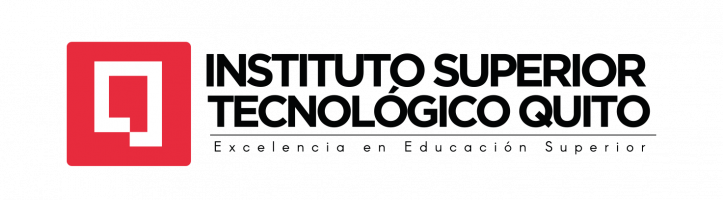

# Programa6.SeleccionAtributos2

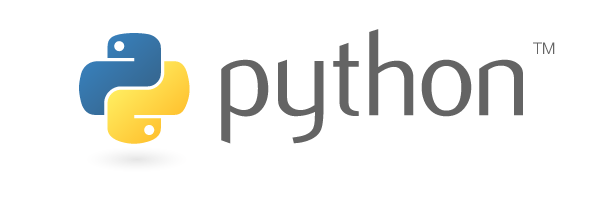

*Oswal Aaron Lopez Carrillo*

[repositorio de git](https://github.com/Aaronlc24/machine)

In [2]:
# Importamos NumPy para generar y trabajar con los datos numéricos.
import numpy as np

# Importamos Matplotlib para realizar las gráficas de los atributos.
import matplotlib.pyplot as plt

# Importamos f_regression para evaluar la relación entre
# cada atributo y la variable objetivo mediante el F-test.
from sklearn.feature_selection import f_regression

# Importamos mutual_info_regression para evaluar
# la información mutua entre los atributos y la variable objetivo.
from sklearn.feature_selection import mutual_info_regression

In [5]:
# Carga de datos
# Fijamos una semilla para que los números aleatorios
# sean reproducibles cada vez que ejecutemos el código.
np.random.seed(42)

# Generamos 1000 observaciones con 3 atributos.
# Los valores se encuentran entre 0 y 1.
X = np.random.rand(1000, 3)

# Mostramos los datos generados.
print(X)

# Mostramos las dimensiones de la matriz.
print(np.shape(X))

[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 ...
 [0.80000348 0.55270708 0.39655368]
 [0.13171503 0.86529576 0.15727321]
 [0.30978786 0.29004553 0.87141403]]
(1000, 3)


In [6]:
# Creamos la variable objetivo y.
# Esta variable depende principalmente de los atributos x1 y x2.
# X[:, 0] corresponde al primer atributo (x1).
# X[:, 1] corresponde al segundo atributo (x2).

y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(1000)

In [8]:
# Evaluamos la relación entre cada atributo de X y la variable objetivo y
# utilizando el F-Test de regresión.
f_test, _ = f_regression(X, y)

# Normalizamos los valores del F-Test dividiendo
# todos los resultados para el valor máximo.
# De esta manera, el atributo con mayor valor tendrá un resultado de 1.
f_test /= np.max(f_test)

In [9]:
# Evaluamos la relación entre cada atributo y la variable objetivo
# utilizando el método de información mutua.
mi = mutual_info_regression(X, y)

# Normalizamos los valores de información mutua.
# El atributo con mayor valor tendrá un resultado igual a 1.
mi /= np.max(mi)

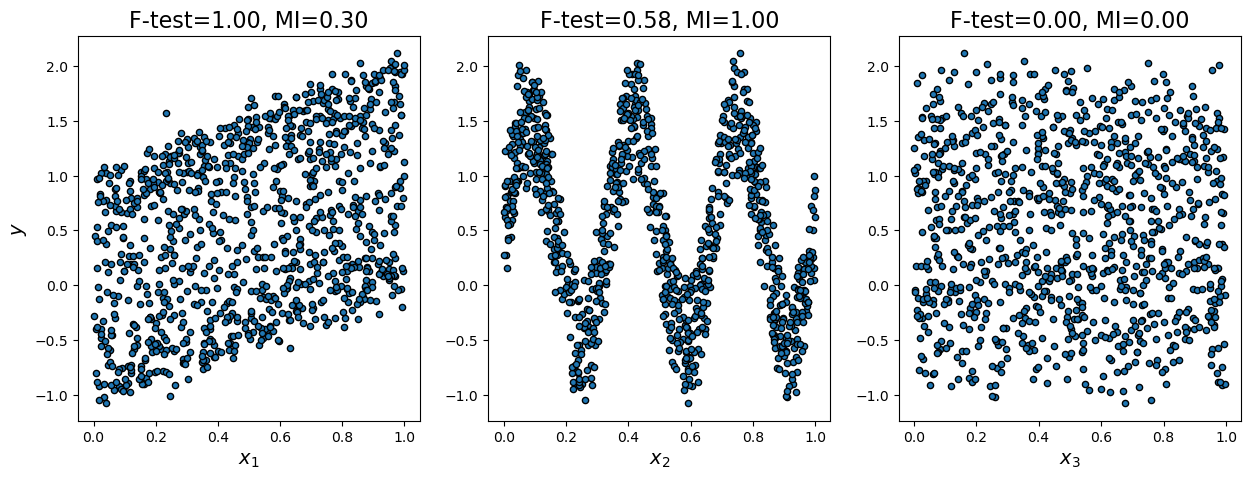

In [10]:
# Creamos una figura con espacio para tres gráficos,
# uno correspondiente a cada atributo.
plt.figure(figsize=(15, 5))

# Recorremos los tres atributos del conjunto de datos.
for i in range(3):

    # Creamos un gráfico de dispersión entre el atributo actual
    # y la variable objetivo.
    plt.subplot(1, 3, i + 1)
    plt.scatter(X[:, i], y, edgecolor='black', s=20)

    # Colocamos el nombre del atributo en el eje X.
    plt.xlabel("$x_{}$".format(i + 1), fontsize=14)

    # Colocamos la etiqueta y solamente en el primer gráfico
    # para evitar repetirla en los tres gráficos.
    if i == 0:
        plt.ylabel("$y$", fontsize=14)

    # Mostramos los valores normalizados obtenidos mediante
    # F-Test e información mutua.
    plt.title(
        "F-test={:.2f}, MI={:.2f}".format(f_test[i], mi[i]),
        fontsize=16
    )

# Mostramos los tres gráficos.
plt.show()